## Lab11: Preprocesamiento de Datos para Machine Learning

Objetivo: Aplicar las principales técnicas de preprocesamiento de datos para preparar un DataSet antes de entrenar un modelo de ML.

    Problema: Se desea construir un modelo capaz de predecir si un psasjero sobrevivio o no al hundimineto del Titanic.

In [1]:
# Importamos Librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [2]:
import kagglehub

In [4]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

100%|██████████| 22.0k/22.0k [00:00<00:00, 55.6kB/s]

Extracting files...


In [5]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\roble\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [6]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [7]:
dfTitanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Parte 1. Comprensión del problema
Determinar si sobreviven al hundimiento del titanic, con base en la información obtenida.

Survived

0-No sobrevivio

1-Sobrevivio

In [8]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

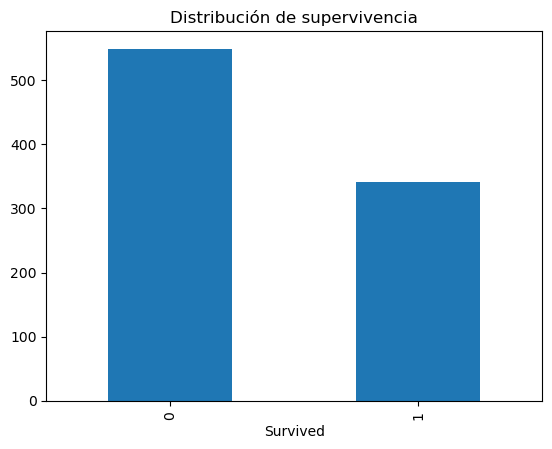

In [10]:
#Graficamos
dfTitanic["Survived"].value_counts().plot(
    kind="bar"
)
plt.title("Distribución de supervivencia")
plt.show()

In [ ]:
## Parte 2

In [11]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# Hipotesis inicial
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [13]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [14]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlación e Hipótesis

Creamos una matriz de correlación para identificar la relación lineal entre las variables. NO identifica la importancia real de variables en el modelo.

In [15]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [16]:
corr = dfTitanic[variables_numericas].corr()

In [17]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


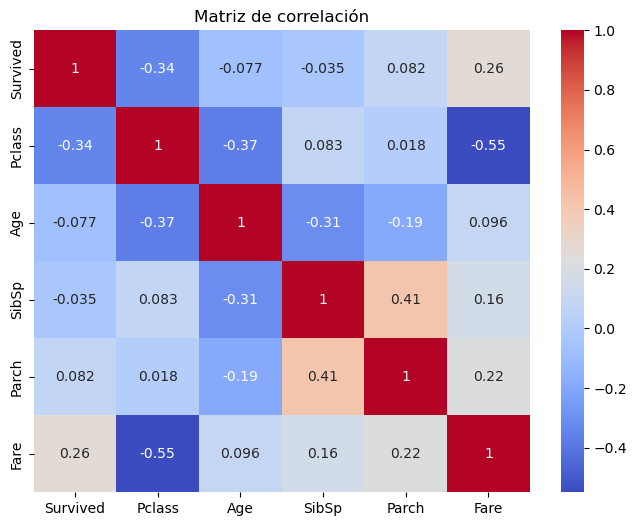

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

## Parte 4. Seleccion de variables predictoras y variable objetivo.

x - Variables que utilizara el modelo

y - Variable que queremos predecir

In [19]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [22]:
# Definimos x y
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [23]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [24]:
print(y.name)

Survived


## Parte 5. Tratamiento de los valores

Para simplificar el proceso, realizaremos la imputación de los datos antes de la sepparación TRAIN/TEST

In [25]:
#Revisamos las variables predictoras
X.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [26]:
X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

C:\Users\roble\AppData\Local\Temp\ipykernel_17728\2953535474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(


In [27]:
X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\roble\AppData\Local\Temp\ipykernel_17728\3303780736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"] = X["Embarked"].fillna(


In [28]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [29]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## Parte 6. Tranformacion de los datos

Los algoritmos no entienden texto. Se deben convertir las variables categoricas en variables numéricas.

In [50]:
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [51]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Parte 7. Particionamos los datos

Nodebemos entrenar y evaluar utilizando los mismos datos.

La recomendación es:

Entrenamiento 80% Pruebas 20%

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state=43
)

In [53]:
print ("Entrenamiento:", X_train.shape)

Entrenamiento: (712, 8)


In [54]:
print ("Prueba:", y_train.shape)

Prueba: (712,)


# Parte 8. Escalado de las variables

Las variables numericas tienen valores distintos. El escalado evita que una variable domine mas que otra.

In [55]:
columnas_numericas = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

In [56]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.000000,712.000000,712.000000,712.000000
mean,29.750239,33.276287,0.528090,0.407303
std,13.144489,52.097510,1.123486,0.850153
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.917700,0.000000,0.000000
50%,28.000000,14.500000,0.000000,0.000000
75%,36.000000,31.275000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [57]:
scaler = StandardScaler()
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)
X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

In [58]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,2.507358e-16,-2.993860e-17,3.991813e-17,2.494883e-17
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00
min,-2.232940e+00,-6.391799e-01,-4.703765e-01,-4.794312e-01
25%,-5.900334e-01,-4.870946e-01,-4.703765e-01,-4.794312e-01
50%,-1.332474e-01,-3.606600e-01,-4.703765e-01,-4.794312e-01
75%,4.758005e-01,-3.844125e-02,4.203364e-01,-4.794312e-01
max,3.825564e+00,9.201777e+00,6.655326e+00,6.583086e+00


# Parte 9. Entrenamiento de los datos

Usaremos un arbol de decision para clasificar registros

In [59]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state = 42
)

In [60]:
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
826,3,-0.133247,-0.470376,-0.479431,0.446007,True,False,True
838,3,0.171277,-0.470376,-0.479431,0.446007,True,False,True
763,1,0.475801,0.420336,1.874741,1.665812,False,False,True
189,3,0.475801,-0.470376,-0.479431,-0.487515,True,False,True
109,3,-0.133247,0.420336,-0.479431,-0.175300,False,True,False
...,...,...,...,...,...,...,...,...
277,2,-0.133247,-0.470376,-0.479431,-0.639180,True,False,True
817,2,0.095146,0.420336,0.697655,0.071607,True,False,False
255,3,-0.057116,-0.470376,1.874741,-0.346334,False,False,False
320,3,-0.590033,-0.470376,-0.479431,-0.499920,True,False,True


In [61]:
modelo.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

# Parte 10. Evaluamos el modelo

Realizamos predicciones para evaluar el modelo

In [62]:
predicciones = modelo.predict(
    X_test
)

In [64]:
pd.DataFrame({
    "Real ": y_test,
"Prediccion ": predicciones
}).head(15)

,Real,Prediccion
770,0,0
853,1,1
144,0,0
141,1,1
261,1,0
11,1,1
794,0,0
390,1,0
15,1,1
675,0,0


# Parte 11.Evaluación del modelo

El accuracy determinar el porcentaje de predicciones correctas realizadas por el modelo

In [66]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [67]:
print ( f"Accuracy :{accuracy: .4f}")

Accuracy : 0.7765


|Accuracy| Interpretacion|
|--------|---------------|
|50% | Adivina|
|60-70% | Aceptable / Basico|
|70-80% | Bueno |
| 80-90% | Muy bueno |
| >90% | Excelente ( posible sobreajuste)|

# Parte 12. Importancia de las variables

Analizar las variables mas relevantes para el algoritmo, al realizar las predicciones

In [69]:
importancias = pd.DataFrame({
    "Variable" : X_train.columns,
    "Importancia" : modelo.feature_importances_ #Que variable es importante para el
})

In [ ]:
importancia.sort_values(
    by="Importancia",
    ascending=False
)